# **Text Preprocessing, Tokenization, and Sequence Padding:**

In [2]:
!pip install gensim -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 16.0 MB/s eta 0:00:00


## **Loading Dataset**

In [3]:
import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
train_dataset_path = '/content/drive/MyDrive/AIML(Assessment)/Part3/7. Racist Sexist or Not Dataset/7. Racist Sexist or Not Dataset/train_racisit.csv'
test_dataset_path = '/content/drive/MyDrive/AIML(Assessment)/Part3/7. Racist Sexist or Not Dataset/7. Racist Sexist or Not Dataset/test_racisit.csv'

In [11]:
train_df = pd.read_csv(train_dataset_path)
train_df.head()

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


In [13]:
# Display tweets with positive label
train_df[train_df["label"] == 1]["tweet"]

,tweet
13,@user #cnn calls #michigan middle school 'buil...
14,no comment! in #australia #opkillingbay #se...
17,retweet if you agree!
23,@user @user lumpy says i am a . prove it lumpy.
34,it's unbelievable that in the 21st century we'...
...,...
31934,lady banned from kentucky mall. @user #jcpenn...
31946,@user omfg i'm offended! i'm a mailbox and i'...
31947,@user @user you don't have the balls to hashta...
31948,"makes you ask yourself, who am i? then am i a..."


In [14]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31962 entries, 0 to 31961
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      31962 non-null  int64 
 1   label   31962 non-null  int64 
 2   tweet   31962 non-null  object
dtypes: int64(2), object(1)
memory usage: 749.2+ KB


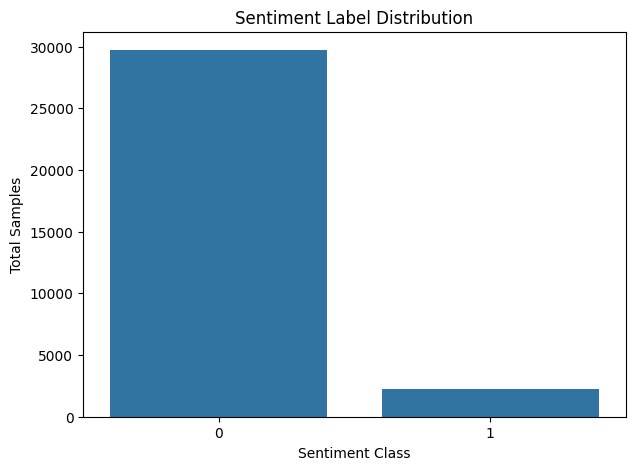

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.countplot(
    data=train_df,
    x="label"
)

plt.title("Sentiment Label Distribution")
plt.xlabel("Sentiment Class")
plt.ylabel("Total Samples")
plt.show()

In [18]:
if "id" in train_df.columns:
    train_df = train_df.drop(
        columns=["id"]
    )
train_df.head()

,label,tweet
0,0,@user when a father is dysfunctional and is s...
1,0,@user @user thanks for #lyft credit i can't us...
2,0,bihday your majesty
3,0,#model i love u take with u all the time in ...
4,0,factsguide: society now #motivation


## **Data Cleaning and Normalization**

In [19]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

#download required NLTK resources
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

#slang replacement dictionary
slang_dict = {
    "gr8": "great",
    "b4": "before",
    "u": "you",
    "ur": "your",
    "r": "are",
    "lol": "laugh",
    "omg": "oh my god",
    "idk": "i do not know",
    "btw": "by the way"
}

#initialize stopwords and lemmatizer
stop_words = set(
    stopwords.words("english")
)

lemmatizer = WordNetLemmatizer()

#text preprocessing function
def preprocess_text(text):
    contractions = {

        "won't": "will not",
        "can't": "can not",
        "n't": " not",
        "'re": " are",
        "'s": " is",
        "'d": " would",
        "'ll": " will",
        "'t": " not",
        "'ve": " have",
        "'m": " am"
    }

    #expand contractions
    for pattern, replacement in contractions.items():

        text = re.sub(
            pattern,
            replacement,
            text
        )

    #remove usernames
    text = re.sub(
        r'\buser\w*\b',
        '',
        text,
        flags=re.IGNORECASE
    )

    #convert to lowercase
    text = text.lower()

    #replace slang words
    for slang, full_word in slang_dict.items():

        text = re.sub(
            r'\b' + re.escape(slang) + r'\b',
            full_word,
            text
        )

    #remove URLs
    text = re.sub(
        r'http\S+|www\S+',
        '',
        text
    )
    #remove mentions and hashtags
    text = re.sub(
        r'@\w+',
        '',
        text
    )
    text = re.sub(
        r'#\w+',
        '',
        text
    )

    #remove emojis
    emoji_pattern = re.compile(
        "["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        "]+",
        flags=re.UNICODE
    )

    text = emoji_pattern.sub(
        ' ',
        text
    )

    #remove punctuation and numbers
    text = re.sub(
        r'[^a-zA-Z\s]',
        '',
        text
    )

    #tokenization
    tokens = text.split()

    #stopword removal and lemmatization
    tokens = [

        lemmatizer.lemmatize(word)

        for word in tokens

        if word not in stop_words
    ]
    return ' '.join(tokens)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [20]:
train_df["cleaned_tweet"] = train_df["tweet"].apply(preprocess_text)

In [21]:
#display updated dataset
train_df

,label,tweet,cleaned_tweet
0,0,@user when a father is dysfunctional and is s...,father dysfunctional selfish drag kid dysfunction
1,0,@user @user thanks for #lyft credit i can't us...,thanks credit use cause offer wheelchair van pdx
2,0,bihday your majesty,bihday majesty
3,0,#model i love u take with u all the time in ...,love take time ur
4,0,factsguide: society now #motivation,factsguide society
...,...,...,...
31957,0,ate @user isz that youuu?ðððððð...,ate isz youuu
31958,0,to see nina turner on the airwaves trying to...,see nina turner airwave trying wrap mantle gen...
31959,0,listening to sad songs on a monday morning otw...,listening sad song monday morning otw work sad
31960,1,"@user #sikh #temple vandalised in in #calgary,...",vandalised condemns act


## **Visualize the cleaned data**

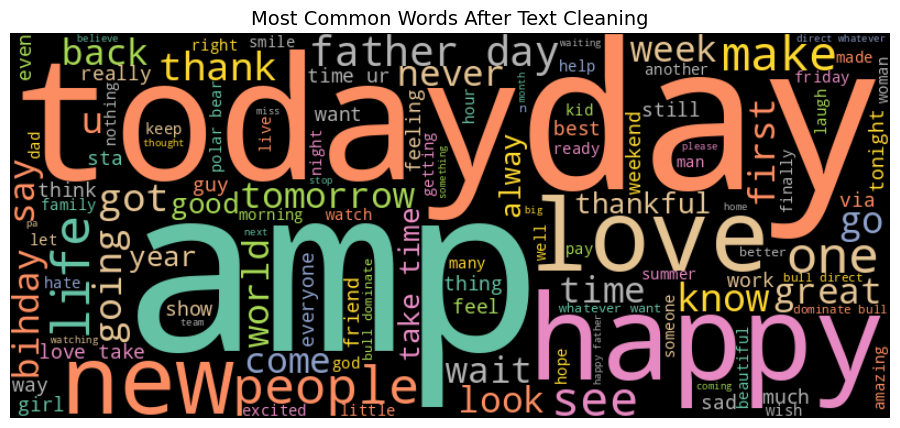

In [22]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
# Combine all cleaned tweets into one text
cleaned_text_data = " ".join(
    train_df["cleaned_tweet"].dropna()
)

# Generate word cloud
tweet_wordcloud = WordCloud(
    width=800,
    height=350,
    background_color="black",
    colormap="Set2",
    max_words=120,
    random_state=42
).generate(cleaned_text_data)

plt.figure(figsize=(12, 5))
plt.imshow(
    tweet_wordcloud,
    interpolation="bilinear"
)
plt.axis("off")
plt.title(
    "Most Common Words After Text Cleaning",
    fontsize=14
)
plt.show()

## **Train Test Split**

In [23]:
from sklearn.model_selection import train_test_split
#split dataset into training and testing sets
train_texts, test_texts, train_labels, test_labels = train_test_split(
    train_df["cleaned_tweet"],
    train_df["label"],
    test_size=0.20,
    shuffle=True,
    random_state=42
)

## **Tokenization and Padding**

In [24]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tweet_tokenizer = Tokenizer(
    num_words=10000,
    oov_token="<OOV>"
)
#build vocabulary from training data
tweet_tokenizer.fit_on_texts(
    train_texts
)
#convert text into integer sequences
train_sequences = tweet_tokenizer.texts_to_sequences(
    train_texts
)
test_sequences = tweet_tokenizer.texts_to_sequences(
    test_texts
)

In [25]:
train_sequences

[[1716, 916, 545, 30, 30],
 [8042, 1077, 8043, 5583, 191, 8044, 178, 8045, 3571],
 [71],
 [164],
 [5584, 8046, 3064],
 [160, 320, 8047, 510, 2420, 607, 115, 608, 327, 253, 836],
 [1483, 292, 951, 8048, 1112, 470, 52, 1484, 4346],
 [8049, 8050, 2012, 46, 28, 72, 5585, 3572, 8051],
 [655, 37, 11, 12, 13, 4],
 [631, 59, 837, 8052],
 [328, 2186, 47],
 [3, 44, 8, 656, 239],
 [10, 632, 1717, 8053, 1718, 868],
 [345, 195, 694, 352, 40],
 [478, 5586, 496, 248, 511, 28, 9, 423, 246, 248, 36],
 [43, 8, 17],
 [],
 [4, 21, 1857, 8054],
 [19, 17, 8055, 12, 44],
 [2187, 8056, 8057],
 [8058, 108],
 [358, 483, 1222, 5587, 2700, 917],
 [3, 1113, 141],
 [97, 2013, 28, 133, 62, 22, 991, 809, 6, 3573, 110],
 [4, 453, 4, 33],
 [162, 51, 2701, 3065, 14, 869, 127],
 [243, 1157, 4347, 5588, 341, 103, 8059, 1023, 227],
 [57, 3574, 8060, 155, 399, 870, 871],
 [50, 1422, 5589, 50, 512, 8061, 11],
 [25, 131, 55, 3066, 8062],
 [48],
 [192, 48],
 [513, 810, 1223, 1588, 137, 1719, 470, 1024, 157],
 [],
 [2, 193, 2],

In [26]:
max_sequence_length = max(
    len(sequence)
    for sequence in train_sequences
)

In [28]:
max_sequence_length

19

In [29]:
test_max_sequence_length = max(
    len(sequence)
    for sequence in test_sequences
)
test_max_sequence_length

21

In [30]:
import numpy as np
sequence_lengths = [
    len(sequence)
    for sequence in train_sequences
    ]
max_sequence_length = int(
    np.percentile(
        sequence_lengths,
        95
    )
)

In [31]:
train_padded_sequences = pad_sequences(
    train_sequences,
    maxlen=max_sequence_length,
    padding="post",
    truncating="post"
)
test_padded_sequences = pad_sequences(
    test_sequences,
    maxlen=max_sequence_length,
    padding="post",
    truncating="post"
)

print(
    "Padding Length Used:",
    max_sequence_length
)

Padding Length Used: 11


In [32]:
train_padded_sequences.shape

(25569, 11)

# **Model Building and Trasining**

## **Simple Recurrent Neural Network**

In [34]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    SimpleRNN,
    Dense
)
vocabulary_size = 10000
embedding_size = 100
sequence_length = max_sequence_length
simple_rnn_units = 64

#simple RNN model
simple_rnn_model = Sequential([
    Embedding(
        input_dim=vocabulary_size,
        output_dim=embedding_size,
        input_length=sequence_length
    ),
    SimpleRNN(
        units=simple_rnn_units,
        return_sequences=False
    ),
    Dense(
        1,
        activation="sigmoid"
    )
])

simple_rnn_model.build(
    input_shape=(None, sequence_length)
)

simple_rnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 11, 100)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │        10,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,010,625 (3.86 MB)

 Trainable params: 1,010,625 (3.86 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
from tensorflow.keras.metrics import Precision, Recall

simple_rnn_model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=[
        "accuracy",
        Precision(),
        Recall()
    ]
)

In [36]:
from keras.callbacks import EarlyStopping
from sklearn.utils import class_weight

#early stopping callback
early_stop_callback = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

#compute balanced class weights
balanced_class_weights = class_weight.compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

#convert weights into dictionary format
class_weight_dictionary = dict(
    enumerate(balanced_class_weights)
)

class_weight_dictionary

{0: np.float64(0.5375478282807047), 1: np.float64(7.158174692049272)}

In [37]:
print("Training Model 1: Simple RNN")

history_simple_rnn = simple_rnn_model.fit(
    train_padded_sequences,
    train_labels,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    class_weight=class_weight_dictionary,
    callbacks=[early_stop_callback],
    verbose=1
)

Training Model 1: Simple RNN
Epoch 1/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.7683 - loss: 0.4958 - precision: 0.1927 - recall: 0.7244 - val_accuracy: 0.8424 - val_loss: 0.3785 - val_precision: 0.2683 - val_recall: 0.7543
Epoch 2/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9326 - loss: 0.1890 - precision: 0.5104 - recall: 0.9268 - val_accuracy: 0.8702 - val_loss: 0.3213 - val_precision: 0.3003 - val_recall: 0.6743
Epoch 3/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9671 - loss: 0.0931 - precision: 0.6886 - recall: 0.9690 - val_accuracy: 0.9007 - val_loss: 0.2788 - val_precision: 0.3604 - val_recall: 0.5829
Epoch 4/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.9758 - loss: 0.0650 - precision: 0.7504 - recall: 0.9795 - val_accuracy: 0.8952 - val_loss: 0.3284 - val_precision: 0.3578 - val_recall: 0.6686
Epoch 5/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9796 - loss: 0.0560 - precision: 0.7838 - recall: 0.9789 - v

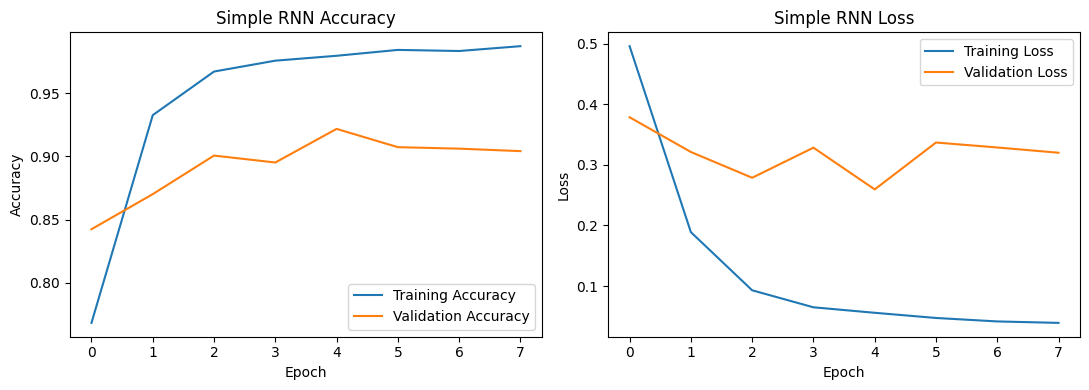

In [38]:
plt.figure(figsize=(11, 4))

# Accuracy graph
plt.subplot(1, 2, 1)
plt.plot(history_simple_rnn.history["accuracy"], label="Training Accuracy")
plt.plot(history_simple_rnn.history["val_accuracy"], label="Validation Accuracy")

plt.title("Simple RNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss graph
plt.subplot(1, 2, 2)
plt.plot(history_simple_rnn.history["loss"], label="Training Loss")
plt.plot(history_simple_rnn.history["val_loss"], label="Validation Loss")

plt.title("Simple RNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

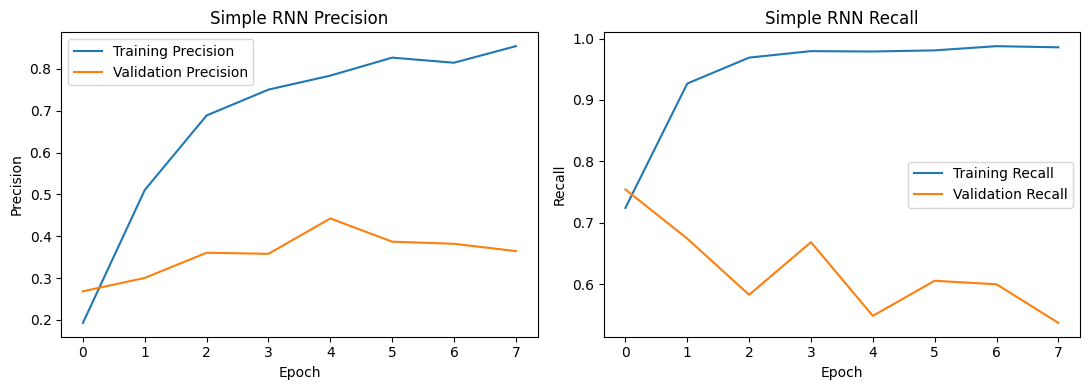

In [39]:
# Precision and Recall graph
plt.figure(figsize=(11, 4))

# Precision plot
plt.subplot(1, 2, 1)
plt.plot(history_simple_rnn.history["precision"], label="Training Precision")
plt.plot(history_simple_rnn.history["val_precision"], label="Validation Precision")

plt.title("Simple RNN Precision")
plt.xlabel("Epoch")
plt.ylabel("Precision")
plt.legend()

# Recall plot
plt.subplot(1, 2, 2)
plt.plot(history_simple_rnn.history["recall"], label="Training Recall")
plt.plot(history_simple_rnn.history["val_recall"], label="Validation Recall")

plt.title("Simple RNN Recall")
plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.legend()

plt.tight_layout()
plt.show()

Evaluating Model 1: Simple RNN

Simple RNN Accuracy: 0.9219


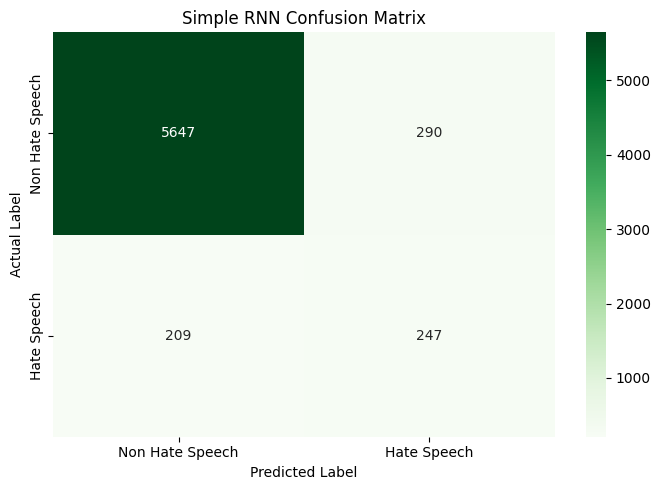


Simple RNN Classification Report:

                 precision    recall  f1-score   support

Non Hate Speech       0.96      0.95      0.96      5937
    Hate Speech       0.46      0.54      0.50       456

       accuracy                           0.92      6393
      macro avg       0.71      0.75      0.73      6393
   weighted avg       0.93      0.92      0.92      6393



In [43]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)
import seaborn as sns

def evaluate_text_model(
    trained_model,
    test_features,
    true_labels,
    model_title
):
    prediction_probabilities = trained_model.predict(
        test_features,
        verbose=0
    )
    predicted_labels = (
        prediction_probabilities > 0.5
    ).astype(int)
    model_accuracy = accuracy_score(
        true_labels,
        predicted_labels
    )

    print(f"\n{model_title} Accuracy: {model_accuracy:.4f}")
    confusion_mat = confusion_matrix(
        true_labels,
        predicted_labels
    )
    plt.figure(figsize=(7, 5))

    sns.heatmap(
        confusion_mat,
        annot=True,
        fmt="d",
        cmap="Greens",
        xticklabels=[
            "Non Hate Speech",
            "Hate Speech"
        ],
        yticklabels=[
            "Non Hate Speech",
            "Hate Speech"
        ]
    )

    plt.title(f"{model_title} Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.tight_layout()
    plt.show()

    print(f"\n{model_title} Classification Report:\n")
    print(
        classification_report(
            true_labels,
            predicted_labels,
            target_names=[
                "Non Hate Speech",
                "Hate Speech"
            ]
        )
    )
    return model_accuracy, predicted_labels

print("Evaluating Model 1: Simple RNN")

simple_rnn_accuracy, simple_rnn_predictions = evaluate_text_model(
    simple_rnn_model,
    test_padded_sequences,
    test_labels,
    "Simple RNN"
)

## **Simple LSTM**

In [44]:
simple_lstm_model = Sequential([
    Embedding(
        input_dim=vocabulary_size,
        output_dim=embedding_size,
        input_length=sequence_length
    ),
    LSTM(
        units=64,
        dropout=0.2,
        recurrent_dropout=0.2
    ),
    Dense(
        1,
        activation="sigmoid"
    )
])
simple_lstm_model.build(
    input_shape=(None, sequence_length)
)
simple_lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 11, 100)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,042,305 (3.98 MB)

 Trainable params: 1,042,305 (3.98 MB)

 Non-trainable params: 0 (0.00 B)

In [45]:
simple_lstm_model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=[
        "accuracy",
        Precision(),
        Recall()
    ]
)

In [46]:
history_simple_lstm = simple_lstm_model.fit(
    train_padded_sequences,
    train_labels,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop_callback],
    class_weight=class_weight_dictionary,
    verbose=1
)

Epoch 1/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.7624 - loss: 0.5111 - precision_1: 0.1827 - recall_1: 0.6890 - val_accuracy: 0.8811 - val_loss: 0.3329 - val_precision_1: 0.3261 - val_recall_1: 0.6914
Epoch 2/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.8879 - loss: 0.2903 - precision_1: 0.3713 - recall_1: 0.8678 - val_accuracy: 0.8295 - val_loss: 0.3971 - val_precision_1: 0.2597 - val_recall_1: 0.8057
Epoch 3/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.9256 - loss: 0.2054 - precision_1: 0.4833 - recall_1: 0.9168 - val_accuracy: 0.9065 - val_loss: 0.2480 - val_precision_1: 0.3933 - val_recall_1: 0.6743
Epoch 4/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.9452 - loss: 0.1534 - precision_1: 0.5646 - recall_1: 0.9466 - val_accuracy: 0.9089 - val_loss: 0.2666 - val_precision_1: 0.3979 - val_recall_1: 0.6457
Epoch 5/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.9542 - loss: 0.1294 - precision_1: 0.6098 - recall_1: 0.

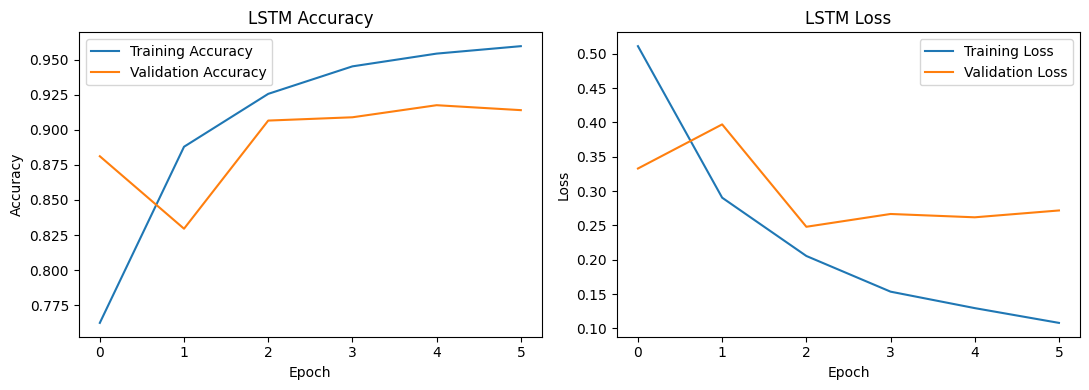

In [50]:
plt.figure(figsize=(11, 4))

# Accuracy graph
plt.subplot(1, 2, 1)
plt.plot(history_simple_lstm.history["accuracy"], label="Training Accuracy")
plt.plot(history_simple_lstm.history["val_accuracy"], label="Validation Accuracy")

plt.title("LSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss graph
plt.subplot(1, 2, 2)
plt.plot(history_simple_lstm.history["loss"], label="Training Loss")
plt.plot(history_simple_lstm.history["val_loss"], label="Validation Loss")

plt.title("LSTM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


Evaluating Model 2: LSTM

LSTM Model Accuracy: 0.9055


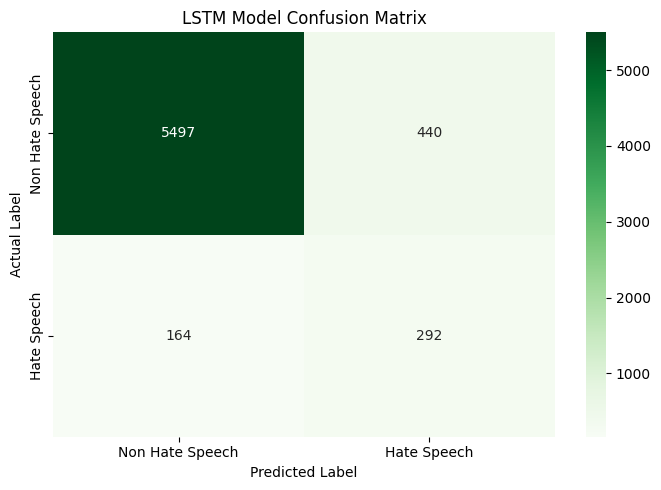


LSTM Model Classification Report:

                 precision    recall  f1-score   support

Non Hate Speech       0.97      0.93      0.95      5937
    Hate Speech       0.40      0.64      0.49       456

       accuracy                           0.91      6393
      macro avg       0.68      0.78      0.72      6393
   weighted avg       0.93      0.91      0.92      6393



In [51]:
print("\nEvaluating Model 2: LSTM")
lstm_accuracy, lstm_predictions = evaluate_text_model(
    simple_lstm_model,
    test_padded_sequences,
    test_labels,
    "LSTM Model"
)

## **LSTM with the Word2Vec**

In [52]:
import gensim.downloader as api

#load pretrained GloVe embedding model
glove_embedding_model = api.load(
    "glove-wiki-gigaword-100"
)

[==================================================] 100.0% 128.1/128.1MB downloaded


In [53]:
checkpoint_path = "/content/drive/MyDrive/AI_ML_Project/simple_rnn_best_model.h5"

best_model_checkpoint = keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    save_weights_only=False
)

In [54]:
import pickle

word_tokenizer = Tokenizer(
    num_words=10000,
    oov_token="<OOV>"
)
#fitting tokenizer on training text
word_tokenizer.fit_on_texts(
    train_texts
)
#saving tokenizer
with open("tokenizer.pkl", "wb") as tokenizer_file:
    pickle.dump(
        word_tokenizer,
        tokenizer_file
    )
vocabulary_size = 10000
embedding_size = glove_embedding_model.vector_size
embedding_matrix = np.zeros(
    (vocabulary_size, embedding_size)
)

# Populate embedding matrix
for word, index in word_tokenizer.word_index.items():

    if index >= vocabulary_size:
        continue

    if word in glove_embedding_model:

        embedding_matrix[index] = glove_embedding_model[word]

glove_lstm_model = Sequential([
    Embedding(
        input_dim=vocabulary_size,
        output_dim=embedding_size,
        weights=[embedding_matrix],
        input_length=sequence_length,
        trainable=False
    ),
    LSTM(64),
    Dense(
        1,
        activation="sigmoid"
    )
])
glove_lstm_model.build(
    input_shape=(None, sequence_length)
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [55]:
embedding_size

100

In [59]:
glove_lstm_model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=[
        "accuracy",
        Precision(),
        Recall()
    ]
)
glove_lstm_model.summary()
train_padded_sequences.shape

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 11, 100)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,042,305 (3.98 MB)

 Trainable params: 42,305 (165.25 KB)

 Non-trainable params: 1,000,000 (3.81 MB)

(25569, 11)

In [60]:
history_glove_lstm = glove_lstm_model.fit(
    train_padded_sequences,
    train_labels,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    callbacks=[
        early_stop_callback,
        best_model_checkpoint
    ],
    class_weight=class_weight_dictionary,
    verbose=1
)

Epoch 1/15
358/360 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6169 - loss: 0.5931 - precision_5: 0.1428 - recall_5: 0.7492

360/360 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.7410 - loss: 0.5079 - precision_5: 0.1807 - recall_5: 0.7641 - val_accuracy: 0.7982 - val_loss: 0.4499 - val_precision_5: 0.2289 - val_recall_5: 0.8229
Epoch 2/15
359/360 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8068 - loss: 0.4355 - precision_5: 0.2369 - recall_5: 0.8045

360/360 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8070 - loss: 0.4289 - precision_5: 0.2395 - recall_5: 0.8076 - val_accuracy: 0.8295 - val_loss: 0.4193 - val_precision_5: 0.2552 - val_recall_5: 0.7771
Epoch 3/15
359/360 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8208 - loss: 0.3938 - precision_5: 0.2516 - recall_5: 0.8207

360/360 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8225 - loss: 0.3890 - precision_5: 0.2589 - recall_5: 0.8243 - val_accuracy: 0.8451 - val_loss: 0.3378 - val_precision_5: 0.2821 - val_recall_5: 0.8171


In [61]:
best_glove_model = keras.models.load_model(
    checkpoint_path
)

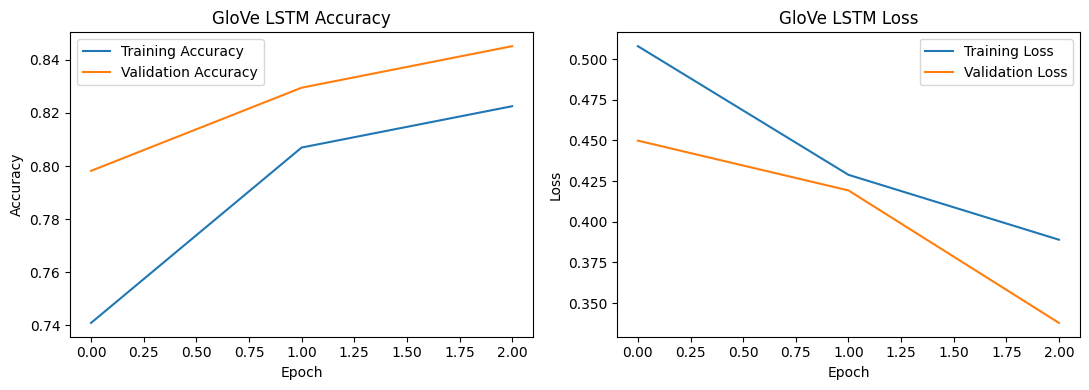

In [62]:
# Training performance visualization
plt.figure(figsize=(11, 4))

# Accuracy graph
plt.subplot(1, 2, 1)
plt.plot(history_glove_lstm.history["accuracy"], label="Training Accuracy")
plt.plot(history_glove_lstm.history["val_accuracy"], label="Validation Accuracy")
plt.title("GloVe LSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss graph
plt.subplot(1, 2, 2)
plt.plot(history_glove_lstm.history["loss"], label="Training Loss")
plt.plot(history_glove_lstm.history["val_loss"], label="Validation Loss")
plt.title("GloVe LSTM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()


Evaluating LSTM Model with GloVe Embeddings:

LSTM with GloVe Embeddings Accuracy: 0.8422


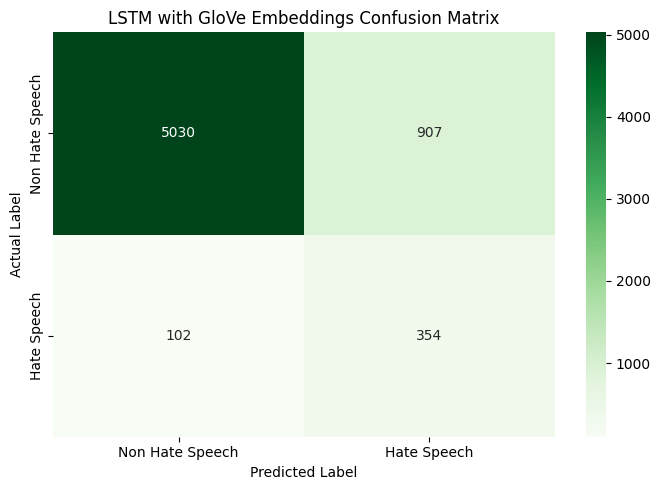


LSTM with GloVe Embeddings Classification Report:

                 precision    recall  f1-score   support

Non Hate Speech       0.98      0.85      0.91      5937
    Hate Speech       0.28      0.78      0.41       456

       accuracy                           0.84      6393
      macro avg       0.63      0.81      0.66      6393
   weighted avg       0.93      0.84      0.87      6393



In [63]:
print("\nEvaluating LSTM Model with GloVe Embeddings:")
glove_lstm_accuracy, glove_lstm_predictions = evaluate_text_model(
    best_glove_model,
    test_padded_sequences,
    test_labels,
    "LSTM with GloVe Embeddings"
)

In [64]:
# Final model performance comparison
model_comparison_table = pd.DataFrame({
    "Model": [
        "Simple RNN",
        "LSTM",
        "LSTM with GloVe"
    ],
    "Accuracy": [
        simple_rnn_accuracy,
        lstm_accuracy,
        glove_lstm_accuracy
    ]
})

print("Final Model Comparison:")
display(model_comparison_table)

# Error analysis for pretrained embedding model
glove_predictions_flat = np.array(
    glove_lstm_predictions
).reshape(-1)

test_labels_array = np.array(
    test_labels
)

incorrect_prediction_indices = np.where(
    glove_predictions_flat != test_labels_array
)[0][:3]

misclassified_samples = []

for sample_index in incorrect_prediction_indices:

    misclassified_samples.append({

        "Tweet Text": test_texts.iloc[sample_index],

        "Actual Label": int(
            test_labels_array[sample_index]
        ),

        "Predicted Label": int(
            glove_predictions_flat[sample_index]
        ),

        "Possible Reason":
        "Tweet may contain sarcasm, ambiguous wording, slang, or unseen contextual patterns."
    })

error_analysis_table = pd.DataFrame(
    misclassified_samples
)

print("Misclassified Tweet Examples:")
display(error_analysis_table)

Final Model Comparison:


,Model,Accuracy
0,Simple RNN,0.921946
1,LSTM,0.905522
2,LSTM with GloVe,0.842171


Misclassified Tweet Examples:


,Tweet Text,Actual Label,Predicted Label,Possible Reason
0,hating conservative homophobe using tragedy wa...,0,1,"Tweet may contain sarcasm, ambiguous wording, ..."
1,global medium platform would much like suppo tv,0,1,"Tweet may contain sarcasm, ambiguous wording, ..."
2,hardly see,0,1,"Tweet may contain sarcasm, ambiguous wording, ..."


In [67]:
import gradio as gr

# Prediction function for Gradio
def predict_hate_speech(input_text):
    cleaned_input = preprocess_text(input_text)

    input_sequence = word_tokenizer.texts_to_sequences(
        [cleaned_input]
    )

    input_padded = pad_sequences(
        input_sequence,
        maxlen=sequence_length,
        padding="post",
        truncating="post"
    )

    prediction_score = best_glove_model.predict(
        input_padded,
        verbose=0
    )[0][0]

    if prediction_score >= 0.5:
        return f"Hate Speech / Offensive Text ({prediction_score:.2%})"

    return f"Non Hate Speech ({prediction_score:.2%})"


#creating Gradio interface
hate_speech_interface = gr.Interface(
    fn=predict_hate_speech,
    inputs=gr.Textbox(
        lines=3,
        placeholder="Enter a tweet or sentence..."
    ),
    outputs="text",
    title="Hate Speech Detection",
    description="This interface predicts whether a given text is hate/offensive or non-hate speech."
)

hate_speech_interface.launch(
    share=True
)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3c58805ebd456c0e8b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
